# OpenMC-Based Physics-Informed Bayesian Optimisation for BWR Fuel Assembly Enrichment Layout

*A sample-efficient, surrogate-guided search for binary-enrichment pin layout design, benchmarked against the Gundremmingen-A BWR 6×6 assembly*

---

## Introduction

This notebook applies Bayesian Optimisation (BO) to the same BWR 6×6 fuel-assembly enrichment-layout problem addressed in the companion GA notebook: arranging a fixed inventory of high- and low-enrichment fuel rods to bring the assembly's infinite multiplication factor, $k_{\infty}$, close to a target value while keeping the pin-wise Power Peaking Factor (PPF) within a safety limit. Each candidate layout is evaluated using **OpenMC** as the neutronics simulator — making each evaluation computationally expensive. The problem is therefore treated as **expensive black-box optimisation**. Rather than exhaustively enumerating layouts or relying on population-based search, BO fits a Gaussian Process (GP) surrogate model to the layouts evaluated so far and uses it to predict, cheaply, which untried layout is most likely to improve on the current best.

The reference case and feasibility criteria follow the same Gundremmingen-A BWR 6×6 benchmark used by Radaideh et al. (2021): a fixed inventory of 23 high-enrichment (2.53 wt%) and 13 low-enrichment (1.87 wt%) rods (average enrichment E = 2.292%), a target k∞ ≈ 1.25, and a PPF safety limit. As in the GA notebook, this inventory split is held fixed throughout — BO searches only over *where* the high-enrichment rods sit among the 21 symmetry-reduced positions (each diagonal position representing one physical pin, each off-diagonal position representing a mirrored pair of two), not over how many there are.

Although the notebook and underlying platform are written generically for an N×N assembly (configurable via `BWR_N` and `N_HIGH_RODS`), every fixed parameter, benchmark comparison, and validated result described below is specific to the N = 6 case. Changing `BWR_N` reframes the problem to a different assembly size and rod inventory that has not been benchmarked or physically validated in this notebook.

---

## 1. Why Bayesian Optimisation Here

Genetic Algorithms explore the design space with a population of candidate layouts evolved over many generations, which works well but typically needs hundreds to thousands of OpenMC evaluations to converge. BO takes a different approach: it spends a small number of evaluations building a GP surrogate that models the relationship between layout and objective score, then uses that surrogate — not another expensive OpenMC run — to decide where to sample next. This makes BO attractive when each OpenMC evaluation is costly and the design space, after symmetry reduction, is modest in size (21 positions here).

This notebook also serves two further roles in the platform. First, the standalone BO result acts as a **baseline** for the companion Hybrid Optimisation notebook (HO-BO), where GA elite chromosomes warm-start the GP surrogate — the comparison directly quantifies how much the GA scouting phase improves on BO alone. Second, BO is a natural **stepping stone** toward more complex search strategies: its surrogate captures a compressed model of the physics landscape that can seed or guide further optimisation, even though standard GP-based BO has known weaknesses on the $21$-dimensional discrete combinatorial space here — the argsort decoding introduces plateaus and non-smoothness that the GP was not originally designed to handle.

---

## 2. Physical Model and Enrichment Representation

| Chromosome Bit | Fuel Type | U-235 Enrichment |
| :---: | :---: | :---: |
| `0` | Low-enrichment UO₂ | 1.87 wt% |
| `1` | High-enrichment UO₂ | 2.53 wt% |

| Parameter | Value |
| :--- | :---: |
| Assembly size | 6×6 (36 pins) |
| Symmetry-reduced positions | 21 |
| High-enrichment rods (fixed) | 23 |
| Low-enrichment rods (fixed) | 13 |
| Average enrichment E | 2.292 wt% |
| Target k∞ | 1.25 |
| PPF limit | < 1.35 |

Because GPs operate on continuous variables, each candidate layout is represented internally as a continuous vector over the 21 symmetry-reduced positions, then **decoded** into a binary enrichment pattern by ranking the 21 continuous values and assigning high enrichment to the top entries — enough to fill the fixed inventory of 23 rods once expanded back across the full symmetry. This keeps the rod count exactly fixed at every evaluation, but it also means the underlying problem stays discrete and combinatorial underneath a continuous BO surface, which has implications for how smooth the objective function actually is (see *Limitations* below).

The OpenMC model represents a single, isolated assembly under **reflective boundary conditions** — the standard way to approximate an infinite, repeating lattice of identical assemblies — so the eigenvalue returned is the assembly's **infinite multiplication factor, k∞**, not the full-core effective multiplication factor, k_eff.

---

## 3. Bayesian Optimisation Workflow

The workflow alternates between **cheap surrogate prediction** and **expensive OpenMC evaluation**, minimising the number of full OpenMC runs needed to find a good design.
```
Phase A — Initialisation (LHS)
  Space-filling samples -> decode -> Run OpenMC -> k∞, PPF, score
              |
              ▼ 
Phase B — Surrogate Fitting (GP)
  Train GP on all (layout, score) pairs collected so far
              |
              ▼
Phase C — Acquisition (EI)
  Score 80,000 candidates cheaply via GP (no OpenMC)
  Select candidate with highest Expected Improvement
              |
              ▼
Phase D — OpenMC Evaluation
  Decode selected candidate -> Run OpenMC -> update dataset
              |
              ▼
  Repeat Phases B–D for n_bo_iterations
```

- **Phase A (LHS)** — generates a space-filling initial dataset; each sample is decoded into a binary layout and evaluated in OpenMC.
- **Phase B (GP)** — fits a Matérn-5/2 ARD Gaussian Process surrogate on all collected (layout, score) pairs; provides predictions and uncertainty estimates without OpenMC.
- **Phase C (EI)** — scores 80,000 candidates cheaply via the GP, balancing **exploitation** (predicted good regions) against **exploration** (uncertain regions); selects the best candidate.
- **Phase D (OpenMC)** — evaluates the selected candidate in OpenMC, adds the result to the dataset, and retrains the GP.
---

## 4. Score Function

Unlike the GA notebook's minimised fitness, this notebook formulates BO as a **maximisation problem**, so the score is written with both penalty terms negated — a perfect layout (k∞ exactly on target, PPF within limit) scores 0, and every deviation subtracts from it:

$$\text{Score} = -\alpha_k \left| k_{\text{target}} - k_{\infty} \right| - \alpha_{\text{PPF}} \max\left(0,\ \text{PPF} - \text{PPF}_{\text{target}}\right)^2$$

| Term | Meaning |
| :--- | :--- |
| $k_{\text{target}}$ | target k∞ (1.25) |
| $\text{PPF}_{\text{target}}$ | PPF limit (1.35) |
| $\alpha_k$ | weight on deviation from the k∞ target |
| $\alpha_{\text{PPF}}$ | weight on PPF-limit violation |

As in the GA notebook, the PPF term only activates once the limit is exceeded, so the optimiser is free to trade off PPF anywhere below the limit while chasing the k∞ target. An optional adjacency penalty can additionally be folded into this score to discourage clustering (see below).

---

## 5. Physics-Informed Constraints

Two optional heuristics bias the search toward physically sensible layouts, identical in spirit to the GA notebook:

- **Corner masking (hard constraint).** Forces the four corner positions to low enrichment by excluding them from the high-enrichment ranking during decoding. Corner pins sit at the assembly boundary where neutron leakage is highest, so keeping them low-enrichment reduces leakage and helps flatten the power distribution.
- **Adjacency penalty (soft constraint).** Adds a penalty proportional to the number of directly adjacent high-enrichment pairs, discouraging — without strictly forbidding — clusters that would otherwise create local power hot spots.

Both are toggles that bias, not override, the underlying OpenMC-computed k∞ and PPF.

---

## 6. Limitations

This notebook is a proof-of-concept demonstration of a surrogate-guided optimisation workflow, **not** a licensed fuel-design tool, and its results should not be read as a final reactor design. Specific limitations:

- **Discrete problem, continuous method.** The enrichment-layout problem is fundamentally discrete and combinatorial, while standard GP-based BO is designed for smooth, continuous objective landscapes. Decoding a continuous vector into a binary layout can introduce non-smoothness that the GP surrogate was not originally designed to model, so convergence guarantees that hold for continuous BO do not strictly transfer here.
- **Monte Carlo statistical noise.** OpenMC evaluations during the BO loop use relatively low particle counts for runtime reasons, injecting statistical noise directly into the surrogate's training data and, in turn, into its predictions.
- **No global-optimum guarantee.** Given the above, the best layout BO finds should be treated as a *promising candidate*, not a guaranteed global optimum — hence the high-fidelity validation step at the end of the notebook, which re-evaluates the best layout at a much higher particle count.
- **No depletion, thermal-hydraulic feedback, control rods, axial effects, or finite-core leakage modelling** — the same scope limitations that apply to the GA notebook's k∞-only, beginning-of-life, infinite-lattice approximation.

For rigorous use, the optimised layout should be re-evaluated at higher particle counts and the model extended with depletion, thermal-hydraulic coupling, axial representation, and additional engineering constraints — alongside a like-for-like comparison against the GA notebook's results.


# User Inputs
**(Change only `BWR_N` and `N_HIGH_RODS` to switch assembly size.)**

In [1]:
BWR_N        = 6    # –––––> Side length of the square assembly
N_HIGH_RODS  = 23   # –––––> Number of high-enrichment rods in the
                    #   full N×N grid (assembly-specific physics input)

import os
##****** Toggles: Both true ––> toggles turned on; Both False ––> turned off **********#####

ENABLE_CORNER_MASKING = True  #True or False         
ENABLE_ADJACENCY_PENALTY = True      #True or False  
ENABLE_ADJACENCY_PENALTY_WEIGHT = 3.0

K_PENALTY = 100       
PPF_PENALTY  = 5   



# HYPERPARAMETER SCALING LOGIC
# Sample counts (LHS and BO_ITERATIONS) must scale up based on two factors:
#********************************************************************************
'''
 Heuristic Constraints: Hard masking reduces the effective search space by removing selected pin positions from the decision process.
                        However, the adjacency penalty is a soft constraint that can make the objective landscape sharper by penalizing
                        clustered high-enrichment layouts. A mildly larger initial LHS sample helps the surrogate model observe this
                        constrained landscape, while a moderate increase in BO iterations gives the optimiser enough refinement steps.

 Assembly Size (NxN): As the assembly size increases, the number of pin positions grows approximately with N^2. The number of possible
                      enrichment layouts grows combinatorially, so larger assemblies may require more initial samples and BO iterations
                      to explore the expanded design space.

'''

# Scale base samples by grid size relative to the 6x6 baseline
base_lhs = int(30 * (BWR_N / 6))    # 30 for 6x6
base_bo  = int(20 * (BWR_N / 6))    # 20 for 6x6

# Heuristics are treated as ON only when both physics-informed options are enabled
use_physics_heuristics = ENABLE_CORNER_MASKING and ENABLE_ADJACENCY_PENALTY

# Mildly increase LHS samples and moderately increase BO iterations when heuristics are active
INITIAL_SAMPLES_LHS = int(base_lhs * 1.2) if use_physics_heuristics else base_lhs
BO_ITERATIONS       = int(base_bo  * 1.5) if use_physics_heuristics else base_bo

# Auto-derived — do not edit
N_TOTAL      = BWR_N ** 2
N_SYM        = BWR_N * (BWR_N + 1) // 2
suffix = "HP-BO" if use_physics_heuristics else "BO"
MODEL_NAME   = f"BWR_{BWR_N}x{BWR_N}_{suffix}"
RESULTS_DIR  = f"../Results/{MODEL_NAME}"
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Setup complete: {MODEL_NAME}")


Setup complete: BWR_6x6_HP-BO


# Imports

In [2]:

import openmc
import sys, os
import warnings
from functools import partial
import matplotlib.pyplot as plt
import numpy as np
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from openmc_bo import (
    RunConfig,
    run_lhs,
    run_bo,
    run_smoke_test,
    summarise_results,
    plot_convergence,
)

from environments.env        import evaluate_for_bo, get_model_params
from environments.bwr_vis    import plot_enr_grid, validate_and_plot_hifi 
from environments.bwr_report import export_design_report

from environments.mapping    import ENR_LOW, ENR_HIGH

from openmc_bo.results       import plot_convergence

print("Imports successful.")

Imports successful.


# BO Configuration

In [3]:

cfg_bo = RunConfig(
    
    n_rods_side  = BWR_N,           # derived from Cell 1
    n_high_rods  = N_HIGH_RODS,     # derived from Cell 1

   
    
     # Physics-informed constraints
    k_target   = 1.25,
    ppf_target = 1.35,
    alpha_k    = K_PENALTY,      # penalty weight for |K_TARGET - k∞|;
    alpha_ppf  = PPF_PENALTY,    # penalty weight for PPF excess^2  
                   # –––––––> To prevent the algorithm from creating localized power spikes by clumping high-enrichment rods in the center

   
    use_corner_masking    = ENABLE_CORNER_MASKING,    # hard mask applied inside cfg.decode()
        ##––––––––> Heuristics: Physics Informed corner masking for High enriched rods 
# Hard mask: Forces corner rods to LOW enrichment by setting their continuous values to -inf. 
#Unlike the adjacency rule, this is a strict constraint, not a soft penalty weight.

    
    use_adjacency_penalty = ENABLE_ADJACENCY_PENALTY,          #––––––––> Soft Penalty to prevent high enriched rods clustering  
    adj_penalty_weight    = ENABLE_ADJACENCY_PENALTY_WEIGHT,     # multiplied by count from env
    
    
    ## BO hyper-parameters
    n_initial_samples = INITIAL_SAMPLES_LHS,         
    n_bo_iterations   = BO_ITERATIONS,
    n_candidates      = 80000,
    ei_xi             = 0.01,
    gp_restarts       = 10,
    random_seed       = 42,

    ## OpenMC particles for Optimisation
    n_particles = 5000,   #5000
    n_inactive  = 25,    #25
    n_active    = 50,    #50

    ## OpenMC particles for smoke test
    n_particles_smoke = 500,
    n_inactive_smoke  = 10,
    n_active_smoke    = 20,


    model_name  = MODEL_NAME,
    results_dir = RESULTS_DIR,
)

# Dependency injection
evaluate_fn = partial(evaluate_for_bo, cfg=cfg_bo)

print(cfg_bo.summary())
print(f"\nBO search space: {cfg_bo.n_vars}-dimensional  "
      f"(auto-set from {BWR_N}×{BWR_N} assembly)")

RunConfig — BWR_6x6_HP-BO
  Assembly           : 6×6 = 36 pins
  Design variables   : 21  
  ENR_LOW            : 1.87 wt%
  ENR_HIGH           : 2.53 wt%
  n_high_rods        : 23 / 36
  k-inf target       : 1.25  (alpha_k = 100)
  PPF target         : 1.35  (alpha_ppf = 5)
  LHS samples        : 36
  BO iterations      : 30
  Corner masking     : True
  Adjacency penalty  : True  (weight=3.0)
  OpenMC particles   : 5000  (25 inactive + 50 active)
  Smoke particles    : 500  (10 inactive + 20 active)
  Results dir        : ../Results/BWR_6x6_HP-BO

BO search space: 21-dimensional  (auto-set from 6×6 assembly)


# Smoke Test

In [4]:

rng_smoke = np.random.default_rng(cfg_bo.random_seed)
smoke_x   = rng_smoke.uniform(0, 1, size=cfg_bo.n_vars)  # size auto-correct for NxN

smoke_res = run_smoke_test(cfg_bo, evaluate_fn, smoke_x)
print(f"k∞  = {smoke_res['keff']:.5f}")
print(f"PPF = {smoke_res.get('ppf', 'N/A')}")
print(f"Corner violations : {smoke_res.get('corner_violations', 'N/A')}")
print(f"Adjacent hi rods  : {smoke_res.get('adj_high_rods',    'N/A')}")

  SMOKE TEST — BWR_6x6_HP-BO
══════════════════════════════════════════════════════════════════════
  Continuous vector (first 6): [0.774 0.439 0.859 0.697 0.094 0.976]
  Decoded grid       : 23 × 2.53%  +  13 × 1.87%  (avg 2.2917 wt%)
  Particles          : 500  (10 inactive + 20 active)

  k∞    = 1.25399 ± 0.00968   (target = 1.25)
  |Δk∞| = 0.00399
  PPF   = 1.1803   (limit ≤ 1.35)   feasible
k∞  = 1.25399
PPF = 1.1802613385701508
Corner violations : 0
Adjacent hi rods  : 22


# LHS seed

In [5]:
lhs_data = run_lhs(cfg_bo, evaluate_fn, verbose=True)

Running 36 LHS samples  [6×6, 21-D continuous relaxation]
  ENR inventory : 23 × 2.53%  +  13 × 1.87%  => avg 2.2917 wt%
  k∞ target     : 1.25   PPF limit ≤ 1.35


LHS samples:   0%|          | 0/36 [00:00<?, ?it/s]

  [ 1/36]  k∞=1.27023 ±0.00201  PPF=1.104  score=-86.02300
  [ 2/36]  k∞=1.26793 ±0.00207  PPF=1.105  score=-79.79296
  [ 3/36]  k∞=1.27407 ±0.00181  PPF=1.103  score=-74.40745
  [ 4/36]  k∞=1.26926 ±0.00188  PPF=1.101  score=-73.92636
  [ 5/36]  k∞=1.27465 ±0.00178  PPF=1.121  score=-80.46523
  [ 6/36]  k∞=1.27366 ±0.00200  PPF=1.104  score=-80.36564
  [ 7/36]  k∞=1.27170 ±0.00213  PPF=1.108  score=-74.16959
  [ 8/36]  k∞=1.27151 ±0.00180  PPF=1.112  score=-92.15149
  [ 9/36]  k∞=1.27181 ±0.00170  PPF=1.124  score=-74.18056
  [10/36]  k∞=1.27167 ±0.00205  PPF=1.102  score=-80.16724
  [11/36]  k∞=1.27112 ±0.00190  PPF=1.116  score=-98.11239
  [12/36]  k∞=1.27199 ±0.00199  PPF=1.103  score=-92.19884
  [13/36]  k∞=1.26991 ±0.00181  PPF=1.102  score=-73.99069
  [14/36]  k∞=1.27179 ±0.00175  PPF=1.103  score=-74.17928
  [15/36]  k∞=1.27552 ±0.00150  PPF=1.108  score=-74.55157
  [16/36]  k∞=1.27378 ±0.00160  PPF=1.114  score=-92.37840
  [17/36]  k∞=1.26989 ±0.00190  PPF=1.107  score=-85.988

# BO

In [6]:
bo_data = run_bo(cfg_bo, evaluate_fn, lhs_data, verbose=True)


GP surrogate — 36 training points
  Kernel : 1.01**2 * Matern(length_scale=[10, 10, 5, 10, 4.81, 10, 10, 10, 1, 10, 2.69, 10, 2.86, 10, 10, 10, 10, 0.777, 10, 10, 10], nu=2.5) + WhiteKernel(noise_level=9.97e-06)
  Log-marginal-likelihood : -44.6743

Running 30 BO iterations …
Objective : − 100·|1.25 − k∞| − 5·max(0, PPF − 1.35)²



BO iterations:   0%|          | 0/30 [00:00<?, ?it/s]

  BO  1 [total=37]:  k∞=1.26945 ±0.00224  |Δk|=0.01945  PPF=1.102  score=-79.94489  best=-67.75915
  BO  2 [total=38]:  k∞=1.27454 ±0.00173  |Δk|=0.02454  PPF=1.102  score=-68.45437  best=-67.75915
  BO  3 [total=39]:  k∞=1.27163 ±0.00151  |Δk|=0.02163  PPF=1.112  score=-80.16270  best=-67.75915
  BO  4 [total=40]:  k∞=1.26841 ±0.00193  |Δk|=0.01841  PPF=1.120  score=-79.84056  best=-67.75915
  BO  5 [total=41]:  k∞=1.26878 ±0.00160  |Δk|=0.01878  PPF=1.128  score=-91.87834  best=-67.75915
  BO  6 [total=42]:  k∞=1.27009 ±0.00201  |Δk|=0.02009  PPF=1.111  score=-62.00949  best=-62.00949
  BO  7 [total=43]:  k∞=1.27192 ±0.00195  |Δk|=0.02192  PPF=1.110  score=-86.19210  best=-62.00949
  BO  8 [total=44]:  k∞=1.27201 ±0.00239  |Δk|=0.02201  PPF=1.100  score=-80.20081  best=-62.00949
  BO  9 [total=45]:  k∞=1.27469 ±0.00176  |Δk|=0.02469  PPF=1.116  score=-80.46909  best=-62.00949
  BO 10 [total=46]:  k∞=1.27056 ±0.00145  |Δk|=0.02056  PPF=1.124  score=-74.05556  best=-62.00949
  BO 11 [t

In [7]:
best         = summarise_results(cfg_bo, bo_data, save=True, verbose=True)
enr_grid_opt = cfg_bo.decode(best["x"])

══════════════════════════════════════════════════════════════════════
  OPTIMAL ENRICHMENT LAYOUT (BO) — BWR_6x6_HP-BO
══════════════════════════════════════════════════════════════════════
  Found at                           : BO (iter 6)
  High-enrichment rods (2.53%)  : 23 / 36
  Average enrichment                 : 2.2917 wt%

  k∞                                 : 1.27009 ± 0.00201
  k∞ target                          : 1.25
  |Δk∞|                              : 0.02009  (2009.5 pcm)
  PPF                                : 1.1114  (target ≤ 1.35)
  PPF constraint                     : SATISFIED  
  Composite score                    : -62.009490
  Total evaluations                  : 66
  Feasible designs found             : 66 / 66
══════════════════════════════════════════════════════════════════════
BO results saved –> ../Results/BWR_6x6_HP-BO/BWR_6x6_HP-BO_all_evaluations.csv


In [8]:
#To check the BO data dimensions 
print(f"Number of evaluations saved: {len(bo_data['keff'])}")
print(f"Number of variables per row: {bo_data['X'].shape[1]}")

Number of evaluations saved: 66
Number of variables per row: 21


# Optimal Design Plot

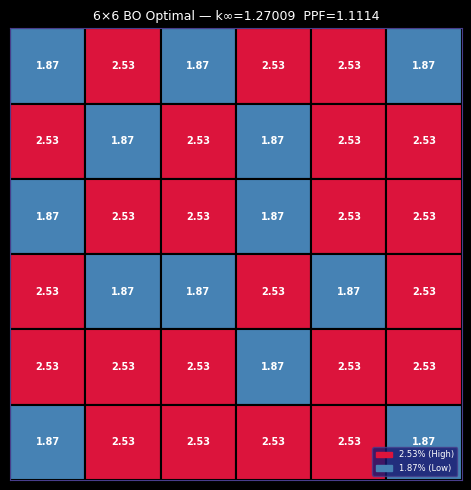

Grid saved → ../Results/BWR_6x6_HP-BO/BWR_6x6_HP-BO_optimal_grid.png


In [9]:

# Save optimal grid immediately
fig_grid, ax = plt.subplots(1, 1, figsize=(5, 5))
fig_grid.patch.set_facecolor("black")
plot_enr_grid(
    enr_grid_opt,
    title = f"{BWR_N}×{BWR_N} BO Optimal — k∞={best['keff']:.5f}  PPF={best['ppf']:.4f}",
    ax    = ax,
)
plt.tight_layout()
grid_path = f"{RESULTS_DIR}/{MODEL_NAME}_optimal_grid.png"
fig_grid.savefig(grid_path, dpi=150, bbox_inches="tight", facecolor="black")
plt.show()
print(f"Grid saved → {grid_path}")

# Convergence plot + text report

Convergence plot saved → ../Results/BWR_6x6_HP-BO/BWR_6x6_HP-BO_bo_convergence.png


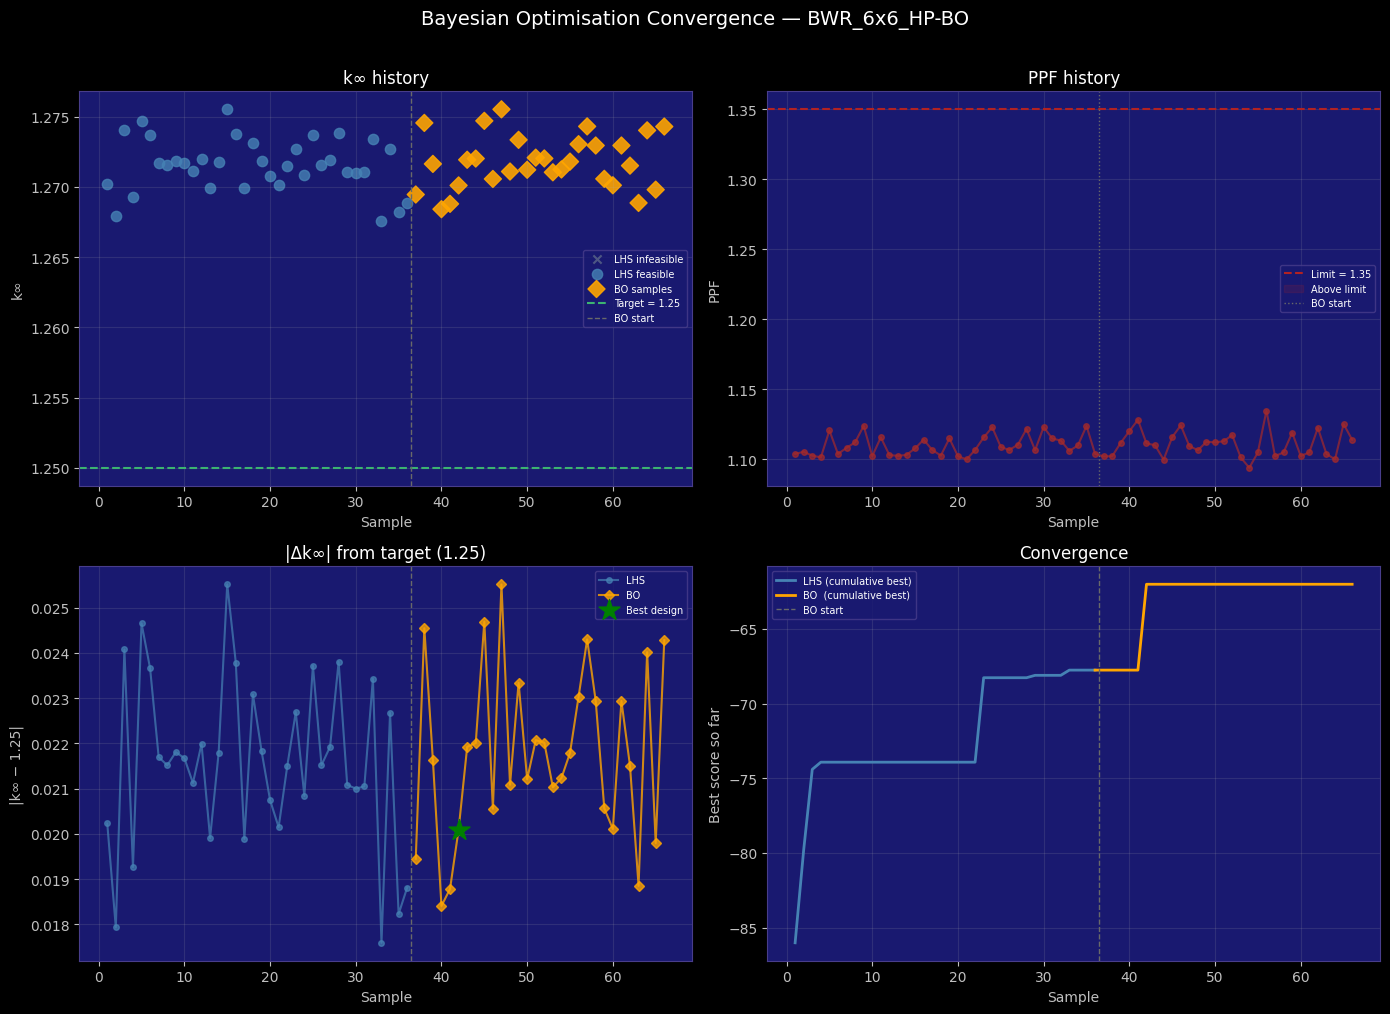

  OPTIMAL 6×6 ENRICHMENT LAYOUT (BO) — BWR_6x6_HP-BO
  Algorithm             : BO
  Assembly size         : 6×6 = 36 fuel pins
  Symmetric positions   : 21  (1/2-diagonal symmetry)
  Enrichment options    : 1.87% (Low)  /  2.53% (High)
  High-enrichment rods  : 23 / 36
  Low-enrichment rods   : 13  / 36
  Average enrichment    : 2.2917 wt%
  k∞                    : 1.27009
  k∞ target             : 1.25
  |Δk∞|                 : 0.02009  (2009.5 pcm)
  PPF                   : 1.1114  (limit ≤ 1.35)
  PPF constraint        : SATISFIED 
  Composite score       : -62.009490

  BO PARAMETERS
  LHS samples           : 36
  BO iterations         : 30
  Candidate pool        : 80000
  EI xi                 : 0.01
  GP restarts           : 10
  Random seed           : 42
  Corner masking        : True
  Adjacency penalty     : True  (weight=3.0)

  GEOMETRY & MATERIAL PARAMETERS
  Layout              : 6 × 6 = 36 fuel pins
  Pin pitch           : 1.62 cm
  Assembly side       : 9.7200 cm
  Fue

'../Results/BWR_6x6_HP-BO/BWR_6x6_HP-BO_report.txt'

In [10]:

fig_conv = plot_convergence(cfg_bo, bo_data, save=True)
plt.show()

export_design_report(
    cfg          = cfg_bo,
    result_data  = best,
    enr_grid_opt = enr_grid_opt,
    model_params = get_model_params(BWR_N),
    filename     = f"{MODEL_NAME}_report.txt",
    algorithm    = "BO",
)



# Comparison and Validation (Not necessary)

  VALIDATION: HIGH-FIDELITY OpenMC RUNS

[A] Reference layout — random valid enrichment layout with 23 high enrichemnt rods

[C] BO best layout — HiFi re-evaluation
All done
════════════════════════════════════════════════════════════════════════
  BO VALIDATION COMPARISON — Enrichment Layout Optimisation
════════════════════════════════════════════════════════════════════════
Design                                                k∞   σ(k∞) pcm      PPF
------------------------------------------------------------------------
  A — Reference layout          [HiFi]           1.27174       26.61   1.1000
  B — BO optimal layout         [LoFi]           1.27009       31.62   1.1114
  C — BO optimal layout (re-run)[HiFi]           1.27174       29.79   1.1049
════════════════════════════════════════════════════════════════════════

  Δk∞  (A→C): +0.00000  (+0.5 pcm)
  ΔPPF (A→C): +0.0049
  Δk∞  (B→C): +0.00165  |Z| = 3.79   check particles

Saved → ../Results/BWR_6x6_HP-BO/BWR_6x6_HP-BO_val

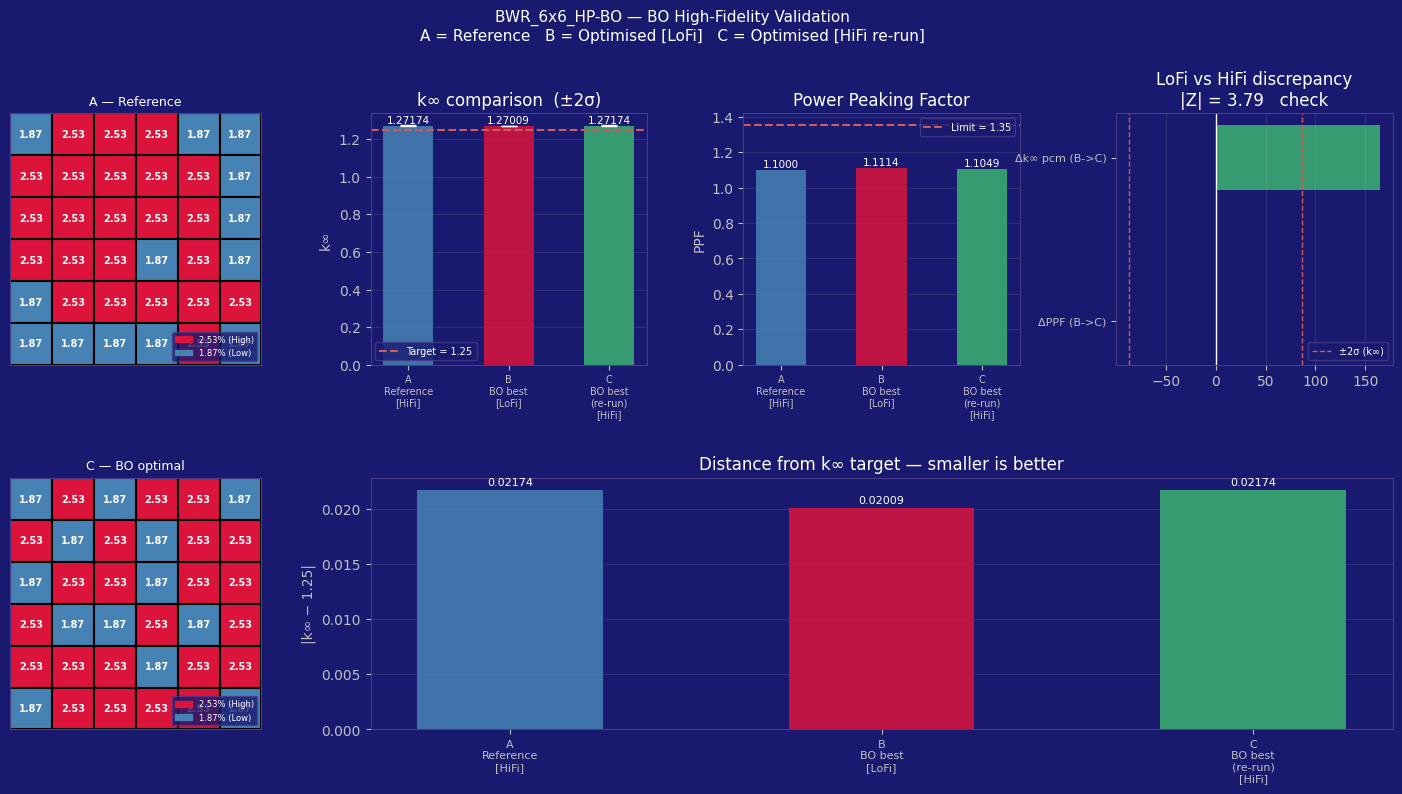

In [11]:

print("=" * 65)
print("  VALIDATION: HIGH-FIDELITY OpenMC RUNS")
print("=" * 65)

# Override particle counts for the HiFi re-evaluation
cfg_bo.n_particles = 50000  #50000+
cfg_bo.n_inactive  = 50
cfg_bo.n_active    = 200


'''
# Reference design: random continuous vector from the smoke test
enr_grid_ref = cfg_bo.decode(smoke_x) 
hifi_ref     = evaluate_fn(smoke_x)
hifi_ref.setdefault("keff_std", 0.0)

'''

# Reference design: random valid enrichment layout (decode from random continuous vector)
print("\n[A] Reference layout — random valid enrichment layout with 23 high enrichemnt rods")

x_ref_random = np.random.uniform(0, 1, size=cfg_bo.n_vars)
enr_grid_ref = cfg_bo.decode(x_ref_random)
hifi_ref = evaluate_fn(x_ref_random)
hifi_ref.setdefault("keff_std", 0.0) 


# Best LoFi result (already computed during BO)
best_lofi = dict(keff=best["keff"], ppf=best["ppf"])

print("\n[C] BO best layout — HiFi re-evaluation")
# Re-run best continuous vector at HiFi particle count
hifi_opt = evaluate_fn(best["x"])
hifi_opt.setdefault("keff_std", 0.0)

print("All done")

# Plotting the convergence and the layouts
fig_val = validate_and_plot_hifi(
    cfg          = cfg_bo,
    hifi_ref     = hifi_ref,
    best_lofi    = best_lofi,
    hifi_opt     = hifi_opt,
    enr_grid_ref = enr_grid_ref,
    enr_grid_opt = enr_grid_opt,
    filename     = f"{MODEL_NAME}_validation.png",
    algorithm    = "BO",
)
plt.show()


